---
title: "Union-Find and Connected Components for Object Detection"
author: "chris"
date: 2026-03-21
draft: false
---

... I recently came across a small issue at work where I began to use a transformer based model for object detection that did not have non-maximal suppression baked into the inference pipeline.  running inference on a model that was not fine-tuned gave back a boatload of overlapping bounding boxes.  the problem got me thinking about connected components and the union-find algorithm and I realized that I could frame collapsing boxes within the confines of graph theory...

In [98]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

boxes = [
    (25, 25, 45, 45),
    (30, 30, 50, 50),
    (35, 35, 55, 55),
    (40, 40, 60, 60),

    (70, 10, 90, 40),
    (77, 14, 97, 44),

    (10, 70, 20, 85),

    (65, 70, 95, 90)
]

In [99]:
def plot_boxes(bboxes):

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect('equal')

    for i, box in enumerate(bboxes):
        x1, y1, x2, y2 = box
        width, height = x2 - x1, y2 - y1
        rect = patches.Rectangle(
            (x1, y1),
            width,
            height,
            linewidth=2,
            edgecolor='black',
            facecolor='none',
            alpha=0.5
            )
        ax.add_patch(rect)
        ax.text(x1,
                y2 + 1,
                f'{i}',
                fontsize=9,
                fontweight='bold'
                )

    plt.title('bounding boxes')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


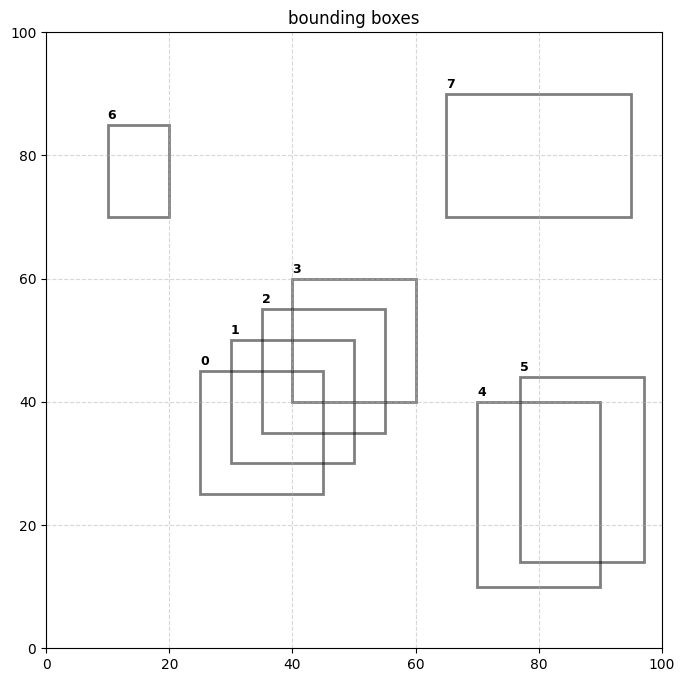

In [100]:
plot_boxes(boxes)

... analagous graph ...

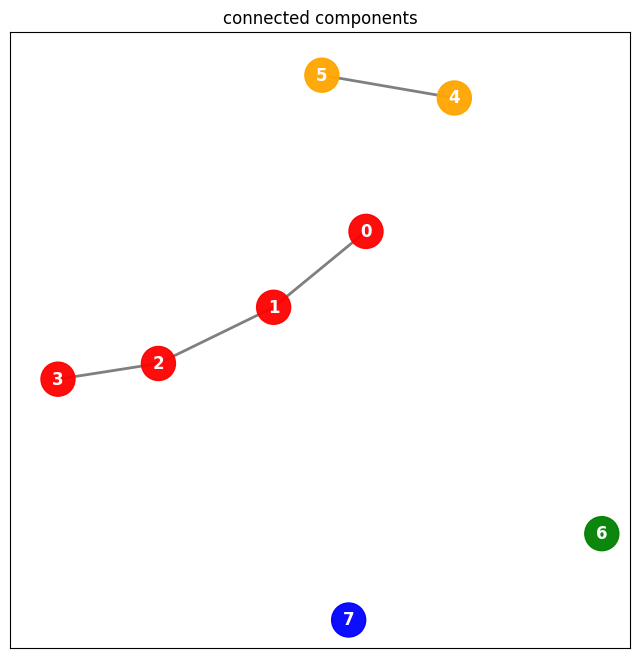

In [101]:
import networkx as nx

G = nx.Graph()
G.add_nodes_from(range(8))
G.add_edges_from([(0, 1), (1, 2), (2, 3)])
G.add_edges_from([(4, 5)])

components = list(nx.connected_components(G))
color_palette = ["red", "orange", "green", "blue"]
node_colors = [None] * 8

for i, component in enumerate(components):
    for node in component:
        node_colors[node] = color_palette[i % len(color_palette)]

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, k=1, iterations=60, seed=42)  # 'k' ~ node distance

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600, alpha=0.95)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color="black")
nx.draw_networkx_labels(G, pos, font_size=12, font_color="white", font_weight="bold")

plt.title("connected components")
plt.show()

In [102]:
def get_iou(box_a, box_b):
    # intersect box
    x_a = max(box_a[0], box_b[0])
    y_a = max(box_a[1], box_b[1])
    x_b = min(box_a[2], box_b[2])
    y_b = min(box_a[3], box_b[3])
    # areas
    intersect_area = max(0, x_b - x_a) * max(0, y_b - y_a)
    box_a_area = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    box_b_area = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    return intersect_area / float(box_a_area + box_b_area - intersect_area)

reduced 8 boxes to 4.


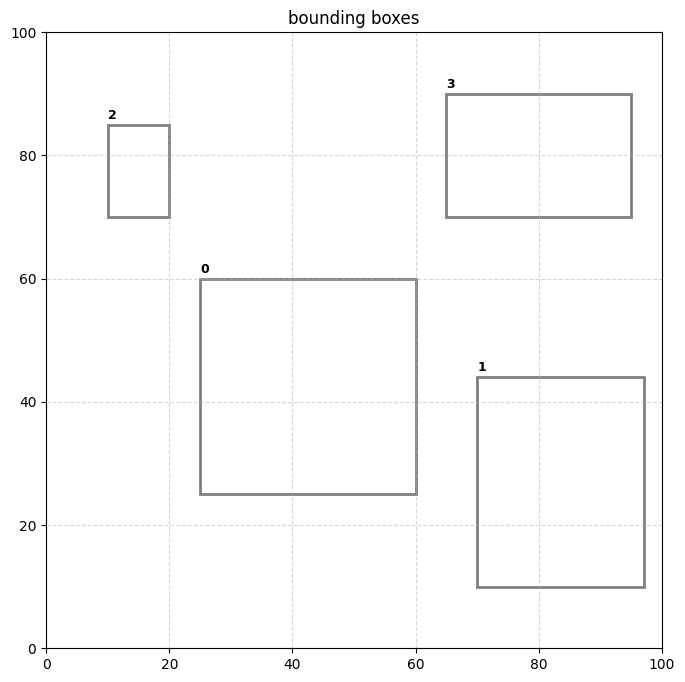

In [103]:
from itertools import combinations

# IOU threshold for merging two boxes
threshold = 0.25

# adjacency list graph representation
graph = {v: set() for v in range(len(boxes))}

# create edges.  edge is if any combination overlaps
for u, v in combinations(range(len(boxes)), 2):
    if get_iou(boxes[u], boxes[v]) > threshold:
        # add to adjacency list
        graph[u].add(v)
        graph[v].add(u)

# print(f"Adjacency List Graph: {graph}")

# parents for union-find
parents = [i for i in range(len(boxes))]

# find goes until a root is found
def find(v):
    while v != parents[v]:
      v = parents[v]
    return v

# union assigns one vertex's parent as the other's parent
def union(u, v):
    root_u = find(u)
    root_v = find(v)
    if root_u != root_v:
        parents[root_v] = root_u

# for every edge in graph perform union to connect components
# NOTE ideally this should be done in edge creation step but more explicit here
seen = set()
for u in graph:
    for v in graph[u]:
        if (u, v) not in seen and (v, u) not in seen:
            union(u, v)
            seen.add((u, v))

# for each connected component keep track of merged box as
# [min x1, min y1, max x2, max y2]
components = {}
for i in range(len(boxes)):
    root = find(i)
    box = boxes[i]
    if root not in components:
        # init as a list to allow mutation
        components[root] = list(box)
    else:
        components[root][0] = min(components[root][0], box[0])  # x1
        components[root][1] = min(components[root][1], box[1])  # y1
        components[root][2] = max(components[root][2], box[2])  # x2
        components[root][3] = max(components[root][3], box[3])  # y2

collapsed_boxes = [tuple(b) for b in components.values()]

print(f"reduced {len(boxes)} boxes to {len(collapsed_boxes)}.")
plot_boxes(collapsed_boxes)

... can optimize with path compression - find procedure links for faster lookups, call to union during graph creation step ...